In [5]:
!pip install matplotlib scikit-learn pandas numpy

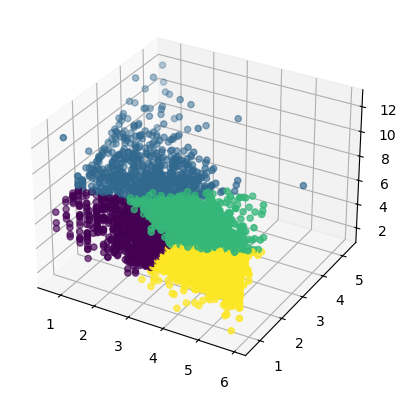

In [29]:
fig=plt.figure()

ax=fig.add_subplot(
111,
projection='3d'
)

ax.scatter(
df_RFM["Recence"],
df_RFM["Frequence"],
df_RFM["Montant"],
c=df_RFM["Cluster"]
)

plt.show()

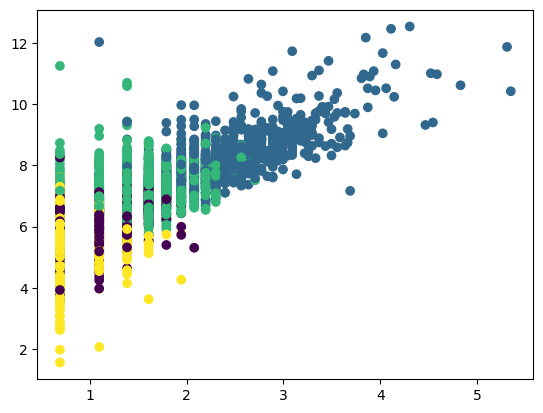

In [28]:
plt.scatter(
df_RFM["Frequence"],
df_RFM["Montant"],
c=df_RFM["Cluster"]
)

plt.show()

In [27]:
cluster_analysis=(
df_RFM.groupby(
"Cluster"
).mean()
)

print(
cluster_analysis
)

          Recence  Frequence   Montant
Cluster                               
0        2.701327   1.090700  6.091552
1        2.160515   2.478709  8.356989
2        4.015904   1.565575  7.251444
3        5.024273   0.814544  5.592418


In [26]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)

df_RFM["Cluster"]=(
kmeans.fit_predict(
RFM_scaled
)
)

In [25]:
for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42
    )

    labels=model.fit_predict(
        RFM_scaled
    )

    score=silhouette_score(
        RFM_scaled,
        labels
    )

    print(
        k,
        score
    )

2 0.43319275011132063
3 0.3360125435154917
4 0.3371343622222519
5 0.31731213206663567
6 0.3142698080619326
7 0.2874792907815653
8 0.26816320360101
9 0.27843999047689816
10 0.2791393695495976


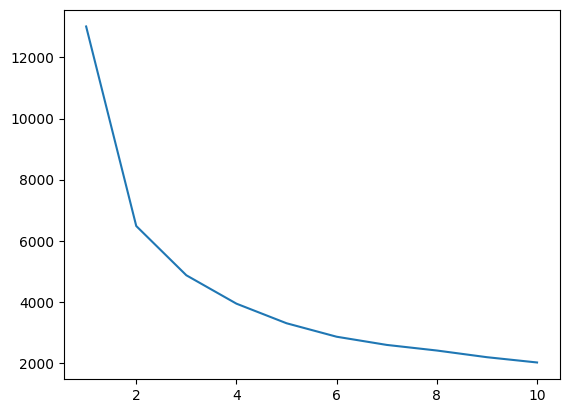

In [24]:
inertia=[]

for k in range(1,11):

    model=KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(
        RFM_scaled
    )

    inertia.append(
        model.inertia_
    )

plt.plot(
range(1,11),
inertia
)

plt.show()

In [23]:
scaler=StandardScaler()

RFM_scaled=scaler.fit_transform(
    df_RFM
)

In [22]:
df_RFM=np.log(
    df_RFM+1
)

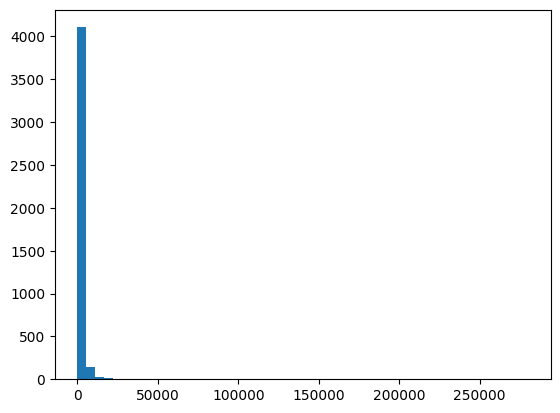

In [21]:
plt.hist(
    df_RFM["Montant"],
    bins=50
)

plt.show()

In [20]:
df_RFM.columns=[
    "Recence",
    "Frequence",
    "Montant"
]

print(
    df_RFM.head()
)

            Recence  Frequence   Montant
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [19]:
df_RFM=df.groupby(
    "CustomerID"
).agg({

"InvoiceDate":
lambda x:
(reference_date-x.max()).days,

"InvoiceNo":"nunique",

"MontantTotal":"sum"

})

In [18]:
reference_date=(
    df["InvoiceDate"].max()
    +
    pd.Timedelta(days=1)
)

In [17]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [16]:
df["MontantTotal"]=(
    df["Quantity"]
    *
    df["UnitPrice"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,MontantTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
df=df[
    df["UnitPrice"]>0
]

In [14]:
df=df[
    df["Quantity"]>0
]

In [13]:
df=df.dropna(
    subset=["CustomerID"]
)

In [12]:
missing=(df.isnull().sum()/len(df))*100

print(missing)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [11]:
start=time.time()

df2=pd.read_parquet(
    "OnlineRetail.parquet"
)

end=time.time()

print(
    "Temps Parquet =",
    end-start
)

Temps Parquet = 1.0117707252502441


In [9]:
# تحويل الأعمدة المختلطة إلى نص

df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["StockCode"] = df["StockCode"].astype(str)

df["Description"] = df["Description"].astype(str)

df["Country"] = df["Country"].astype(str)

# حفظ بصيغة Parquet
df.to_parquet(
    "OnlineRetail.parquet",
    engine="pyarrow"
)

print("Parquet créé avec succès")

Parquet créé avec succès


In [37]:
!pip install pyarrow

   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
    --------------------------------------- 0.5/27.3 MB 4.2 MB/s eta 0:00:07
   - -------------------------------------- 1.0/27.3 MB 3.0 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/27.3 MB 2.5 MB/s eta 0:00:11
   -- ------------------------------------- 1.8/27.3 MB 2.4 MB/s eta 0:00:11
   --- ------------------------------------ 2.1/27.3 MB 2.1 MB/s eta 0:00:12
   --- ------------------------------------ 2.4/27.3 MB 2.0 MB/s eta 0:00:13
   --- ------------------------------------ 2.6/27.3 MB 2.0 MB/s eta 0:00:13
   ---- ----------------------------------- 3.1/27.3 MB 1.9 MB/s eta 0:00:13
   ----- ---------------------------------- 3.4/27.3 MB 1.8 MB/s eta 0:00:14
   ----- ---------------------------------- 3.7/27.3 MB 1.8 MB/s eta 0:00:14
   ----- ---------------------------------- 3.9/27.3 MB 1.8 MB/s eta 0:00:14
   ------ ---

In [10]:
import time
import pandas as pd

start = time.time()

df = pd.read_excel(
    "Online Retail.xlsx",
    engine="openpyxl"
)

end = time.time()

excel_time = end-start

print(
    "Temps Excel =",
    excel_time
)

Temps Excel = 109.07912516593933


In [5]:
print(df.shape)
print(df.info())

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [4]:
import pandas as pd

df = pd.read_excel(
    r"Online Retail.xlsx",
    sheet_name=0,
    engine="openpyxl"
)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
import os

print(os.listdir())

['Online Retail.xlsx', 'projet.ipynb']


In [2]:
file = open("Online Retail.xlsx", "rb")
print(file.read(50))
file.close()

b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00b\xee\x9dh^\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml '


In [16]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from mpl_toolkits.mplot3d import Axes3D

In [ ]:
import os

print(os.listdir())

['Online Retail.xlsx', 'projet.ipynb']


In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()